# Stacking and Blending (1/2) — Stacking with scikit-learn

Voting gives every model an equal vote. **Stacking** trains one more model — the *meta-model* — to learn **which base
model to trust, and how much**. Does that actually help on a small medical dataset? Let's measure it honestly.

**In this notebook**
1. Load the heart-disease data
2. The original experiment: one train/test split
3. How good is each single model? (cross-validation)
4. StackingClassifier vs VotingClassifier vs the best single model
5. Look inside: which base model does the meta-model trust?
6. `passthrough`: give the meta-model the original features too
7. StackingRegressor on a regression dataset

> 📖 Theory: [`theory.md`](theory.md) §1, §4, §7–§10 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold, RepeatedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, StackingClassifier,
                              VotingClassifier, RandomForestRegressor, GradientBoostingRegressor, StackingRegressor)
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_diabetes

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load the heart-disease data

303 patients (UCI heart-disease data), 13 clinical features (age, chest-pain type `cp`, max heart rate `thalach`, ...).
`target = 1` means heart disease.

In [2]:
df = pd.read_csv('heart.csv')
X = df.drop(columns=['target'])
y = df['target']
print('shape:', df.shape)
print('class counts:', y.value_counts().to_dict())
df.head()

shape: (303, 14)
class counts: {1: 165, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


The classes are roughly balanced (165 vs 138), so **accuracy** is a reasonable metric here.

## 2. The original experiment: one train/test split

This is the experiment from the original lecture code: three base models (Random Forest with 10 trees, KNN with
k = 10, Gradient Boosting), a logistic-regression meta-model, `cv=10`, and **one** 80/20 split.

> ✍️ **Core code: learn this.** The basic `StackingClassifier` recipe: a list of `(name, model)` base models + a `final_estimator`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

estimators = [
    ('rf',   RandomForestClassifier(n_estimators=10, random_state=42)),
    ('knn',  KNeighborsClassifier(n_neighbors=10)),
    ('gbdt', GradientBoostingClassifier(random_state=42)),
]
stack_orig = StackingClassifier(estimators=estimators,
                                final_estimator=LogisticRegression(max_iter=1000),
                                cv=10)
stack_orig.fit(X_train, y_train)
print('test rows:', len(X_test))
print('stacking test accuracy:', round(accuracy_score(y_test, stack_orig.predict(X_test)), 3))

test rows: 61
stacking test accuracy: 0.869


**Be careful with this number.** The test set has only 61 patients, so **one patient = 1.6 % accuracy**. A
different `random_state` could easily move the score by several percent. Also, this KNN is **not scaled**: KNN uses
distances, and here `chol` (≈ 200–400) dominates `sex` (0/1).

From now on we fix both problems:
- scale features for KNN and logistic regression with a `Pipeline` (theory §7),
- compare models with **repeated cross-validation** (5 folds × 5 repeats = 25 scores per model) instead of one split.

## 3. How good is each single model?

> ✍️ **Core code: learn this.** Put the scaler *inside* a pipeline, so in every CV fold it is fitted only on that fold's training part.

In [4]:
rf   = RandomForestClassifier(n_estimators=100, random_state=42)
knn  = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=10))
gbdt = GradientBoostingClassifier(random_state=42)
lr   = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

singles = {'Random Forest': rf, 'KNN (scaled)': knn, 'Gradient Boosting': gbdt, 'Logistic Reg. (scaled)': lr}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = {}
for name, model in singles.items():
    scores[name] = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

pd.DataFrame({'mean acc': {k: v.mean() for k, v in scores.items()},
              'std':      {k: v.std()  for k, v in scores.items()}}).round(3).sort_values('mean acc', ascending=False)

,mean acc,std
Logistic Reg. (scaled),0.829,0.043
Random Forest,0.822,0.044
KNN (scaled),0.820,0.052
Gradient Boosting,0.796,0.045


All four single models land in the same ~80–83 % range, and their standard deviations (~4–5 %) are larger
than the gaps between them. The simple, scaled **logistic regression is the best single model** (0.829) on this small
dataset; Gradient Boosting is the weakest (0.796).

## 4. StackingClassifier vs VotingClassifier vs the best single model

We build:
- **Hard voting** and **soft voting** of RF + KNN + GBDT (fixed, equal weights),
- **Stacking (3)**: RF + KNN + GBDT with a logistic-regression meta-model (`cv=5` → out-of-fold predictions, theory §4),
- **Stacking (4)**: the same plus the scaled logistic regression as a fourth base model.

> ✍️ **Core code: learn this.** Stacking vs voting: same base models, the only difference is *how* their outputs are combined.

In [5]:
base3 = [('rf', rf), ('knn', knn), ('gbdt', gbdt)]
base4 = base3 + [('lr', lr)]

ensembles = {
    'Hard voting (3)': VotingClassifier(base3, voting='hard'),
    'Soft voting (3)': VotingClassifier(base3, voting='soft'),
    'Stacking (3)':    StackingClassifier(base3, final_estimator=LogisticRegression(max_iter=1000), cv=5),
    'Stacking (4)':    StackingClassifier(base4, final_estimator=LogisticRegression(max_iter=1000), cv=5),
}
for name, model in ensembles.items():
    scores[name] = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

results = pd.DataFrame({'mean acc': {k: v.mean() for k, v in scores.items()},
                        'std':      {k: v.std()  for k, v in scores.items()}}).round(3)
results.sort_values('mean acc', ascending=False)

,mean acc,std
Logistic Reg. (scaled),0.829,0.043
Stacking (4),0.824,0.047
Random Forest,0.822,0.044
KNN (scaled),0.820,0.052
Hard voting (3),0.820,0.041
Soft voting (3),0.816,0.043
Stacking (3),0.815,0.043
Gradient Boosting,0.796,0.045


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

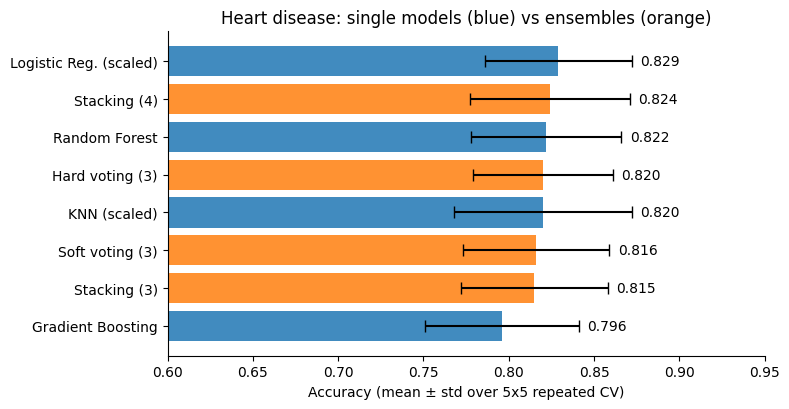

In [6]:
res = results.sort_values('mean acc')
colors = ['tab:orange' if ('Stack' in n or 'voting' in n) else 'tab:blue' for n in res.index]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(res.index, res['mean acc'], xerr=res['std'], color=colors, alpha=0.85, capsize=4)
for i, (m, s) in enumerate(zip(res['mean acc'], res['std'])):
    ax.text(m + s + 0.005, i, f'{m:.3f}', va='center')
ax.set_xlim(0.6, 0.95)
ax.set_xlabel('Accuracy (mean ± std over 5x5 repeated CV)')
ax.set_title('Heart disease: single models (blue) vs ensembles (orange)')
plt.tight_layout(); plt.show()

### Honest verdict: stacking did **not** win here

- **Stacking (3)** scored 0.815. That is better than its weakest base model (Gradient Boosting, 0.796) but slightly
  **worse** than Random Forest (0.822), KNN (0.820) and both voting ensembles (0.820 / 0.816).
- **Stacking (4)** (with logistic regression added as a base model) scored 0.824 — second place, but still just below
  **logistic regression alone (0.829)**, the best model overall.
- Every difference in this table is **much smaller than one standard deviation** (~0.04–0.05). Statistically, all
  these models are tied.

Why no gain? With 303 rows, each training fold has only ~240 patients. The meta-model learns its weights from ~240
out-of-fold predictions, so the weights are noisy, and the base models are similar in skill and make many of the same
mistakes. On a small, fairly "linear" dataset like this, a simple model is very hard to beat. Stacking tends to pay off
on larger datasets with strong, diverse base models (theory §10). **Measuring this is the lesson — do not assume
an ensemble is always better.**

## 5. Look inside: which base model does the meta-model trust?

Fit Stacking (3) on the training split from §2 and look at two things:
1. `transform()` — the **meta-features** the meta-model sees. Binary problem → one probability column per base model
   (theory §8, `stack_method`).
2. `final_estimator_.coef_` — the learned weight for each base model.

> ✍️ **Core code: learn this.** `transform` shows the meta-features; `final_estimator_.coef_` shows how much each base model is trusted.

In [7]:
stack3 = StackingClassifier(base3, final_estimator=LogisticRegression(max_iter=1000), cv=5)
stack3.fit(X_train, y_train)

meta_features = pd.DataFrame(stack3.transform(X_test), columns=['p_rf', 'p_knn', 'p_gbdt'])
print('meta-features for the first 5 test patients (P(disease) from each base model):')
print(meta_features.head().round(3))

coefs = pd.Series(stack3.final_estimator_.coef_[0], index=['rf', 'knn', 'gbdt'])
print('\nmeta-model coefficients:'); print(coefs.round(2))
print('intercept:', stack3.final_estimator_.intercept_.round(2))
print('\ntest accuracy on the 61-row split:', round(stack3.score(X_test, y_test), 3))

meta-features for the first 5 test patients (P(disease) from each base model):
   p_rf  p_knn  p_gbdt
0  0.79    0.8   0.876
1  0.53    0.8   0.828
2  0.81    1.0   0.978
3  0.08    0.0   0.007
4  0.16    0.1   0.024

meta-model coefficients:
rf      2.17
knn     2.50
gbdt    0.47
dtype: float64
intercept: [-2.65]

test accuracy on the 61-row split: 0.869


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

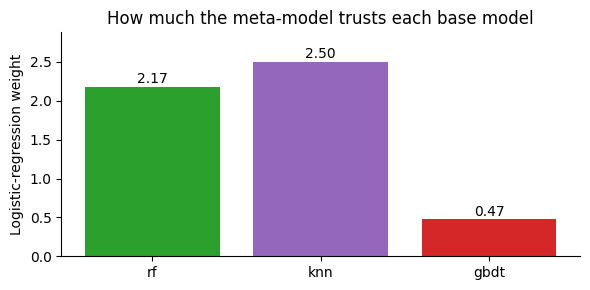

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(coefs.index, coefs.values, color=['tab:green', 'tab:purple', 'tab:red'])
for i, v in enumerate(coefs.values):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center')
ax.set_ylim(0, coefs.max() * 1.15)
ax.set_ylabel('Logistic-regression weight')
ax.set_title('How much the meta-model trusts each base model')
plt.tight_layout(); plt.show()

All three columns are probabilities on the same 0–1 scale, so the weights can be compared directly.
The meta-model gives the **largest weights to KNN (2.50) and Random Forest (2.17)** and a much **smaller weight to
Gradient Boosting (0.47)**. This matches §3, where Gradient Boosting was the weakest single model. This is the
"weighted, not democracy" idea from theory §1: soft voting would have given GBDT the same say as the others.

(On this particular 61-row split the stack scores 0.869 — the same as the original experiment — but remember §2:
one small split is not a reliable comparison. The weights are learned from *out-of-fold* predictions; notebook 02
shows what goes wrong if you use in-sample predictions instead.)

## 6. `passthrough`: give the meta-model the original features too

With `passthrough=True` the meta-model sees `[p_rf, p_knn, p_gbdt, age, sex, cp, ...]` — 3 + 13 = 16 inputs.
Because the raw features have very different scales, we scale inside the meta-model as well. For a fair comparison
both versions use the same meta-model pipeline.

> ✍️ **Core code: learn this.** `passthrough=True` appends the original features to the meta-features.

In [9]:
meta = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pt = {
    'passthrough=False': StackingClassifier(base3, final_estimator=meta, cv=5, passthrough=False),
    'passthrough=True':  StackingClassifier(base3, final_estimator=meta, cv=5, passthrough=True),
}
pt_scores = {name: cross_val_score(m, X, y, cv=cv, scoring='accuracy', n_jobs=-1) for name, m in pt.items()}
n_meta = {name: m.fit(X_train, y_train).transform(X_test).shape[1] for name, m in pt.items()}
pd.DataFrame({'mean acc': {k: v.mean() for k, v in pt_scores.items()},
              'std':      {k: v.std()  for k, v in pt_scores.items()},
              'meta-model inputs': n_meta}).round(3)

,mean acc,std,meta-model inputs
passthrough=False,0.814,0.045,3
passthrough=True,0.820,0.044,16


`passthrough=True` scores slightly higher (0.820 vs 0.814). That makes sense: the meta-model is a logistic
regression, and §3 showed that logistic regression on the scaled raw features is the strongest single model, so
passthrough lets the meta-model use that linear signal directly. But the gap (0.006) is tiny compared with the
standard deviation (~0.045), so treat it as "no harm, maybe a little help", not as a proven improvement.

## 7. StackingRegressor on a regression dataset

Stacking works the same way for regression: base models predict numbers, and a simple regressor (default `RidgeCV`)
combines them. Dataset: sklearn's built-in **diabetes** data (442 patients, 10 features, target = disease progression
one year later). Metric: **R²** (1 = perfect, 0 = as good as always predicting the mean).

> ✍️ **Core code: learn this.** `StackingRegressor` has the same interface as `StackingClassifier`.

In [10]:
Xd, yd = load_diabetes(return_X_y=True, as_frame=True)

reg_base = [
    ('ridge', make_pipeline(StandardScaler(), RidgeCV())),
    ('knn',   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15))),
    ('rf',    RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42)),
    ('gbr',   GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)),
]
reg_models = dict(reg_base)
reg_models['Stacking'] = StackingRegressor(reg_base, final_estimator=RidgeCV(), cv=5)

cv_reg = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
reg_scores = {name: cross_val_score(m, Xd, yd, cv=cv_reg, scoring='r2', n_jobs=-1) for name, m in reg_models.items()}
reg_results = pd.DataFrame({'mean R2': {k: v.mean() for k, v in reg_scores.items()},
                            'std':     {k: v.std()  for k, v in reg_scores.items()}}).round(3)
reg_results.sort_values('mean R2', ascending=False)

,mean R2,std
ridge,0.479,0.074
Stacking,0.473,0.072
gbr,0.459,0.073
rf,0.442,0.080
knn,0.440,0.049


In [11]:
stack_reg = reg_models['Stacking'].fit(Xd, yd)
print('meta-model (RidgeCV) weights:')
print(pd.Series(stack_reg.final_estimator_.coef_, index=[n for n, _ in reg_base]).round(3))

meta-model (RidgeCV) weights:
ridge    0.530
knn      0.422
rf       0.192
gbr     -0.039
dtype: float64


Same story as for classification:
- The stacked regressor (R² = 0.473) beats three of its four base models (GBR 0.459, RF 0.442, KNN 0.440) but is
  slightly **below plain Ridge regression (0.479)**. The gap is far smaller than the standard deviation (~0.07).
- The meta-model gives the biggest weights to **Ridge (0.53)** and **KNN (0.42)**, a small weight to RF (0.19) and
  about zero to GBR (−0.04). The diabetes target is known to be fairly linear, so the linear model carries most of the
  signal; the trees add little the meta-model can use.
- Note: these regression weights are on the target scale (each base prediction is in the same units as `y`), and here
  they sum to about 1.1 — the meta-model is essentially computing a weighted average of the base predictions.

## Key takeaways

- `StackingClassifier(estimators, final_estimator, cv)` trains base models, makes **out-of-fold** predictions with
  `cv`, and fits a meta-model on them. `StackingRegressor` is the same for regression.
- The meta-model **learns weights** (here: high for KNN and RF, low for GBDT) instead of giving every model an equal vote.
- On heart.csv (303 rows), stacking did **not** beat the best single model (scaled logistic regression, 0.829); the
  best stack reached 0.824, and all models were within one standard deviation of each other. The same happened on the
  diabetes regression data (stack R² 0.473 vs Ridge 0.479). Small data → little or no gain.
- Always compare with **cross-validation**, not a single 61-row test split.
- Scale features for KNN / logistic regression with a `Pipeline`, also inside the meta-model when `passthrough=True`.

## 🧠 Quick check

<details><summary>In a binary problem with 3 base models and <code>passthrough=False</code>, how many input columns does the meta-model get?</summary>
3 — one probability column per base model (sklearn drops the redundant P(class 0) column).</details>

<details><summary>Why did we not trust the single-split accuracy from §2?</summary>
It came from one split with only 61 test rows (one patient = 1.6 %), and the KNN was unscaled. Repeated
cross-validation gives a much more reliable estimate.</details>

<details><summary>What does a large meta-model coefficient for a base model mean?</summary>
The meta-model relies strongly on that model's predicted probability: it "trusts" that model more when combining.</details>

<details><summary>Stacking did not clearly beat the best single model here. Does that mean stacking is useless?</summary>
No. It means on this small dataset there was little extra signal to gain. Stacking tends to help more with larger
datasets and diverse, strong base models. Always measure instead of assuming.</details>

➡️ **Next:** [`02-blending-and-stacking-by-hand.ipynb`](02-blending-and-stacking-by-hand.ipynb) — build blending and
K-fold stacking yourself and see why naive stacking leaks.